**2.Chargement et Nettoyage des Données**

In [41]:
import pandas as pd
df = pd.read_csv('dataset_parking.csv')

In [42]:
df.head(10)

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48
5,BHMBCCMKT01,577,177,2016-10-04 10:26:49
6,BHMBCCMKT01,577,219,2016-10-04 10:59:48
7,BHMBCCMKT01,577,247,2016-10-04 11:25:47
8,BHMBCCMKT01,577,259,2016-10-04 11:59:44
9,BHMBCCMKT01,577,266,2016-10-04 12:29:45


In [43]:
# 1. Supprimer les valeurs négatives dans 'Occupancy'
df_clean = df[df['Occupancy'] >= 0].copy()
df_clean.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


**3. Analyse Exploratoire (EDA)**

Extraire des caractéristiques temporelles :

In [44]:
# 2. Convertir 'LastUpdated' en format datetime
df_clean['LastUpdated'] = pd.to_datetime(df_clean['LastUpdated'])
# 3. Extraire des caractéristiques temporelles
df_clean['Hour'] = df_clean['LastUpdated'].dt.hour
df_clean['DayOfWeek'] = df_clean['LastUpdated'].dt.dayofweek  # Lundi=0, Dimanche=6
df_clean['Day'] = df_clean['LastUpdated'].dt.day
df_clean['Month'] = df_clean['LastUpdated'].dt.month
df_clean.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Hour,DayOfWeek,Day,Month
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,7,1,4,10
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,8,1,4,10
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42,8,1,4,10
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46,9,1,4,10
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48,9,1,4,10


In [45]:
df_clean.describe(include='all')

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Hour,DayOfWeek,Day,Month
count,35705,35705.000000,35705.000000,35705,35705.000000,35705.000000,35705.000000,35705.000000
unique,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BHMBCCMKT01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1397.858507,642.445596,2016-11-11 18:16:43.772608768,11.786416,2.888727,15.158661,10.881417
min,NaN,220.000000,0.000000,2016-10-04 07:46:28,7.000000,0.000000,1.000000,10.000000
25%,NaN,500.000000,210.000000,2016-10-24 16:33:03,10.000000,1.000000,8.000000,10.000000
50%,NaN,849.000000,446.000000,2016-11-11 14:27:18,12.000000,3.000000,15.000000,11.000000
75%,NaN,2009.000000,798.000000,2016-11-29 13:28:30,14.000000,5.000000,22.000000,11.000000
max,NaN,4675.000000,4327.000000,2016-12-19 16:30:35,16.000000,6.000000,31.000000,12.000000


In [46]:
print(df_clean.isnull().sum())

SystemCodeNumber    0
Capacity            0
Occupancy           0
LastUpdated         0
Hour                0
DayOfWeek           0
Day                 0
Month               0
dtype: int64


In [47]:
print(df_clean.shape)

(35705, 8)


In [63]:

df_clean.describe(include='all')

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Hour,DayOfWeek,Day,Month
count,35705,35705.000000,35705.000000,35705,35705.000000,35705.000000,35705.000000,35705.000000
unique,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BHMBCCMKT01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1397.858507,642.445596,2016-11-11 18:16:43.772608768,11.786416,2.888727,15.158661,10.881417
min,NaN,220.000000,0.000000,2016-10-04 07:46:28,7.000000,0.000000,1.000000,10.000000
25%,NaN,500.000000,210.000000,2016-10-24 16:33:03,10.000000,1.000000,8.000000,10.000000
50%,NaN,849.000000,446.000000,2016-11-11 14:27:18,12.000000,3.000000,15.000000,11.000000
75%,NaN,2009.000000,798.000000,2016-11-29 13:28:30,14.000000,5.000000,22.000000,11.000000
max,NaN,4675.000000,4327.000000,2016-12-19 16:30:35,16.000000,6.000000,31.000000,12.000000



Résumé des caractéristiques temporelles :
               Hour     DayOfWeek           Day         Month
count  35705.000000  35705.000000  35705.000000  35705.000000
mean      11.786416      2.888727     15.158661     10.881417
std        2.617373      1.994214      8.290535      0.752059
min        7.000000      0.000000      1.000000     10.000000
25%       10.000000      1.000000      8.000000     10.000000
50%       12.000000      3.000000     15.000000     11.000000
75%       14.000000      5.000000     22.000000     11.000000
max       16.000000      6.000000     31.000000     12.000000


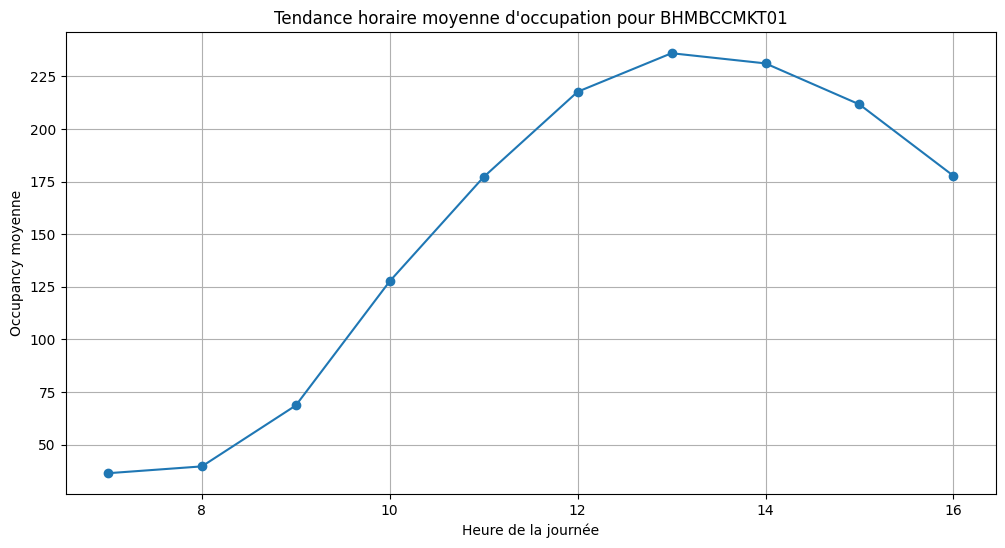

In [65]:

# 4. Afficher un résumé des nouvelles colonnes
print("\nRésumé des caractéristiques temporelles :")
print(df_clean[['Hour', 'DayOfWeek', 'Day', 'Month']].describe())

# 5. Visualiser les tendances d'occupation par heure pour un parking spécifique
import matplotlib.pyplot as plt

# Sélectionner un parking pour l'exemple
parking_example = df_clean['SystemCodeNumber'].iloc[0]
parking_data = df_clean[df_clean['SystemCodeNumber'] == parking_example]

plt.figure(figsize=(12, 6))
plt.plot(parking_data.groupby('Hour')['Occupancy'].mean(), marker='o')
plt.xlabel('Heure de la journée')
plt.ylabel('Occupancy moyenne')
plt.title(f'Tendance horaire moyenne d\'occupation pour {parking_example}')
plt.grid()
plt.show()

In [50]:
df_clean.to_csv('dataset_parking_nettoye.csv', index=False)

**4. Préparation des Données pour le Modèle**

In [68]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. On donne enfin au modèle l'information du parking ! (One-Hot Encoding)
df_encoded = pd.get_dummies(df_clean, columns=['SystemCodeNumber'], drop_first=True)

# 2. On sélectionne les variables (Heure, Jour, Capacité + tous les noms de parkings créés)
features_cols = ['Hour', 'DayOfWeek', 'Capacity'] + [col for col in df_encoded.columns if 'SystemCodeNumber_' in col]

X = df_encoded[features_cols]
y = df_encoded['Occupancy']

# 3. Séparation Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
df_encoded.shape

(35705, 36)

In [70]:
df_encoded.head()

,Capacity,Occupancy,LastUpdated,Hour,DayOfWeek,Day,Month,SystemCodeNumber_BHMBCCPST01,SystemCodeNumber_BHMBCCSNH01,SystemCodeNumber_BHMBCCTHL01,...,SystemCodeNumber_NIA North,SystemCodeNumber_NIA South,SystemCodeNumber_Others-CCCPS105a,SystemCodeNumber_Others-CCCPS119a,SystemCodeNumber_Others-CCCPS133,SystemCodeNumber_Others-CCCPS135a,SystemCodeNumber_Others-CCCPS202,SystemCodeNumber_Others-CCCPS8,SystemCodeNumber_Others-CCCPS98,SystemCodeNumber_Shopping
0,577,61,2016-10-04 07:59:42,7,1,4,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,577,64,2016-10-04 08:25:42,8,1,4,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,577,80,2016-10-04 08:59:42,8,1,4,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,577,107,2016-10-04 09:32:46,9,1,4,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,577,150,2016-10-04 09:59:48,9,1,4,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
df_encoded.to_csv('dataset_parking_encoded.csv', index=False)

5. Entraînement du Modèle
Choisir un algorithme (ex. : Random Forest) :

In [82]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [83]:
from joblib import dump

# Sauvegarder le modèle
dump(model, 'modele_prediction_occupation.joblib')

['modele_prediction_occupation.joblib']

6. Évaluation du Modèle
Prédire sur l’ensemble de test :

In [84]:
y_pred = model.predict(X_test)

Évaluer les performances avec des métriques :


In [85]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculer le MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

# Calculer le RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Calculer le R² (R squared)
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

RMSE: 147.88531014154216
R²: 0.946978681814885


7. Interprétation et Visualisation des Résultats
Comparer les prédictions avec les valeurs réelles :

Le modèle se trompe en moyenne de : 79.53 places de parking.


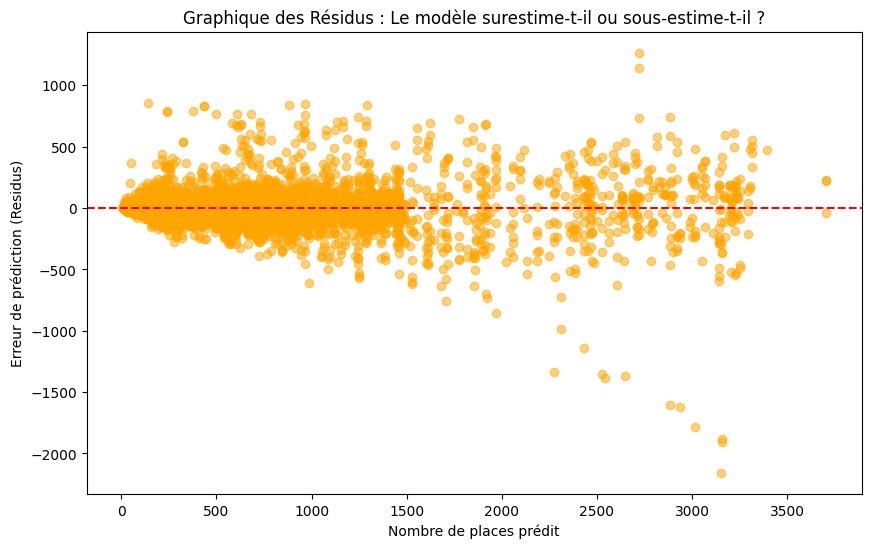

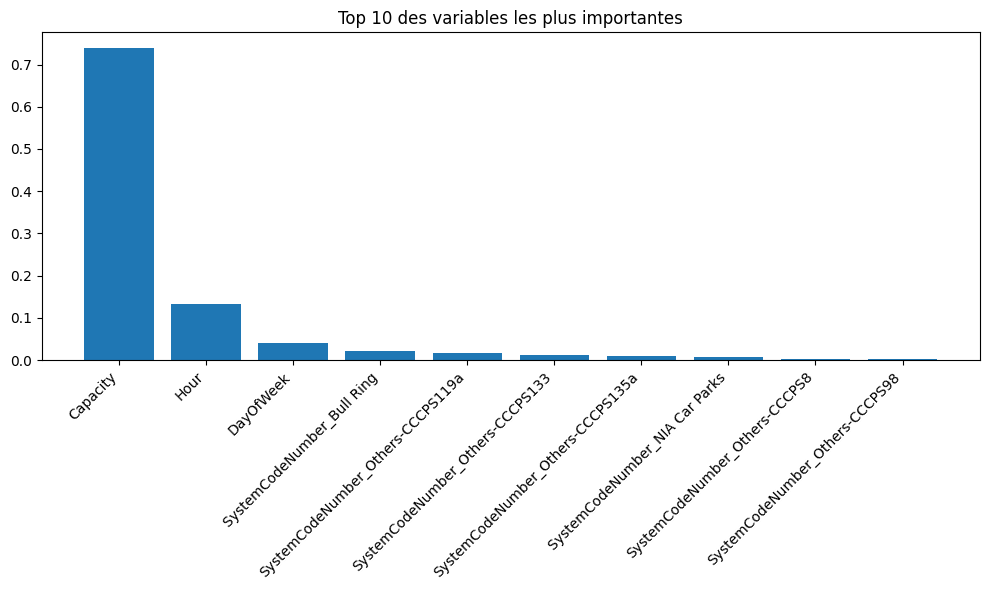

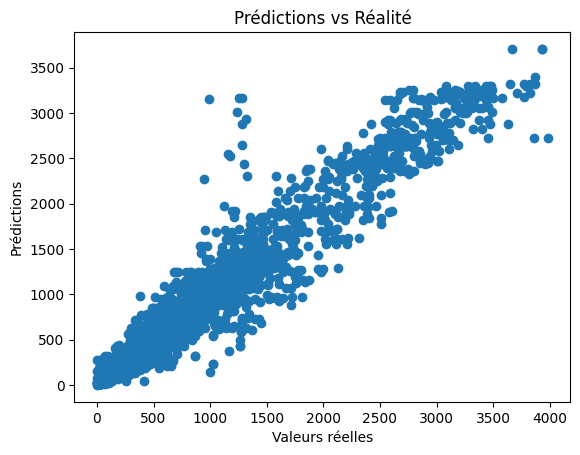

In [88]:
from sklearn.metrics import mean_absolute_error

# 1. Calcul de la MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)
print(f"Le modèle se trompe en moyenne de : {mae:.2f} places de parking.")

# 2. Graphique des Résidus (Analyse des erreurs)
residus = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residus, alpha=0.5, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Nombre de places prédit")
plt.ylabel("Erreur de prédiction (Residus)")
plt.title("Graphique des Résidus : Le modèle surestime-t-il ou sous-estime-t-il ?")
plt.show()

# 3. Importance des variables (Feature Importance)
import numpy as np
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # On affiche le Top 10

plt.figure(figsize=(10,6))
plt.title("Top 10 des variables les plus importantes")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réalité")
plt.show()


8. Optimisation et Amélioration (Optionnel)
a. Ajuster les hyperparamètres du modèle
Pour améliorer les performances du modèle, vous pouvez utiliser des techniques comme GridSearchCV ou RandomizedSearchCV pour trouver les meilleurs hyperparamètres.

Exemple avec GridSearchCV :

In [89]:
from sklearn.model_selection import GridSearchCV

# Définir les hyperparamètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Créer un objet GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1)

# Exécuter la recherche sur les données d'entraînement
grid_search.fit(X_train, y_train)

# Afficher les meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Utiliser le meilleur modèle
best_model = grid_search.best_estimator_

Meilleurs hyperparamètres : {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}


In [79]:
from sklearn.ensemble import RandomForestRegressor

# Utiliser les meilleurs hyperparamètres
best_params = {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10}  # Exemple de meilleurs hyperparamètres

# Créer le modèle avec les meilleurs hyperparamètres
best_model = RandomForestRegressor(**best_params, random_state=42)

# Entraîner le modèle sur l'ensemble des données d'entraînement
best_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=10, n_estimators=200,
                      random_state=42)

In [80]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prédire sur l'ensemble de test
y_pred = best_model.predict(X_test)

# Calculer le RMSE et le R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")

RMSE: 147.77116804065352
R²: 0.9470604969607472


In [81]:
from joblib import dump

# Sauvegarder le modèle optimisé
dump(best_model, 'meilleur_modele_prediction_occupation.joblib')

['meilleur_modele_prediction_occupation.joblib']